# W04 Case Study

#### This section of code below was done by Angela Chen

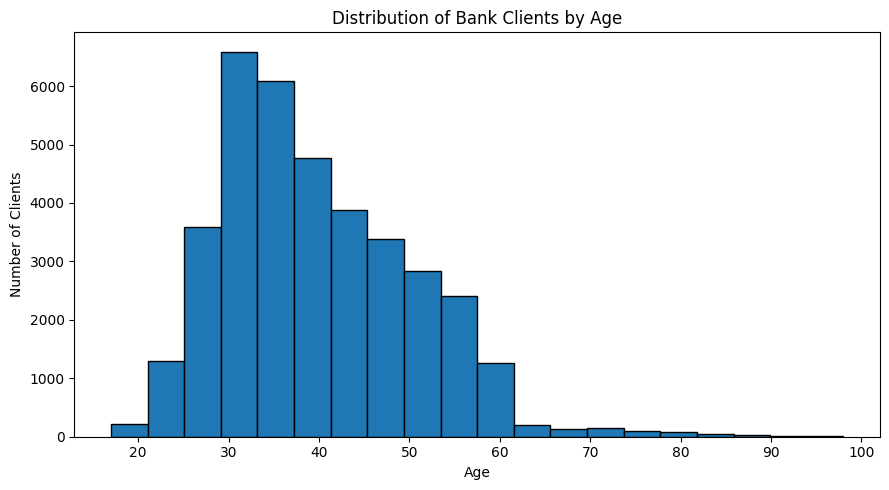

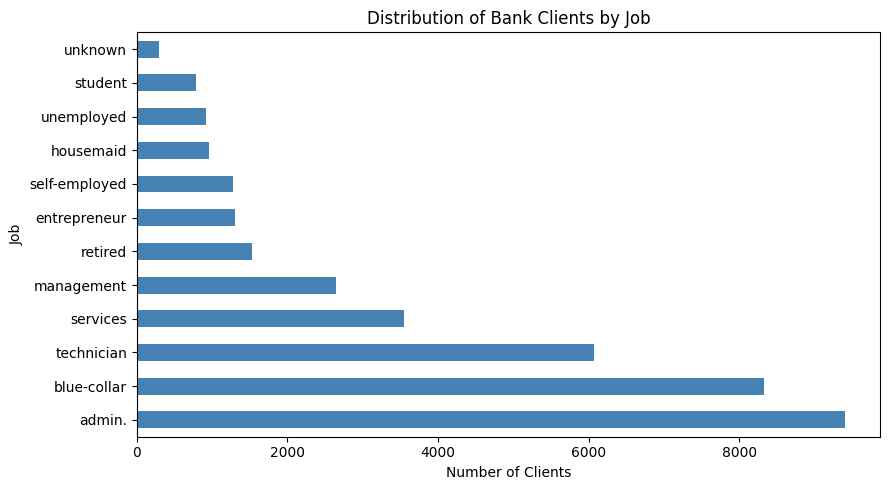

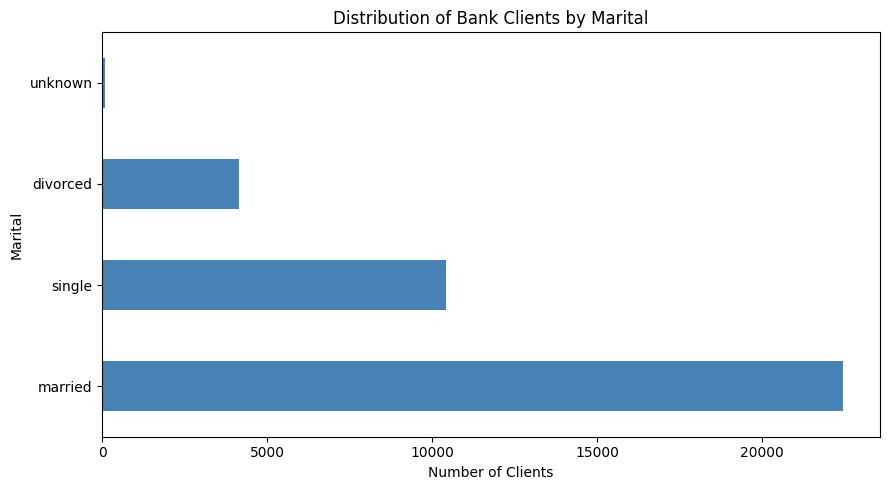

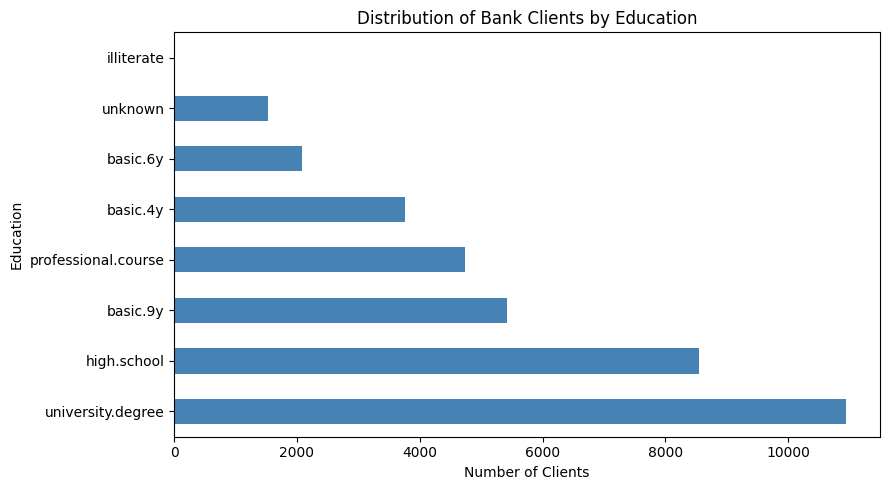

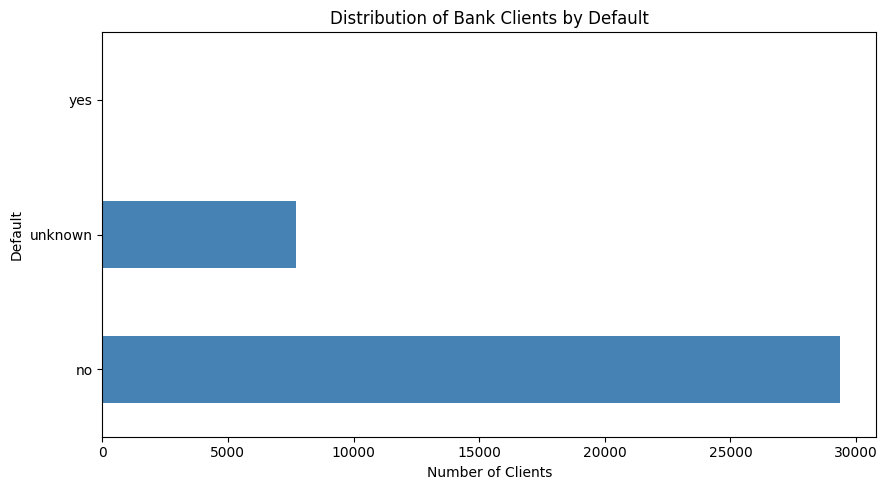

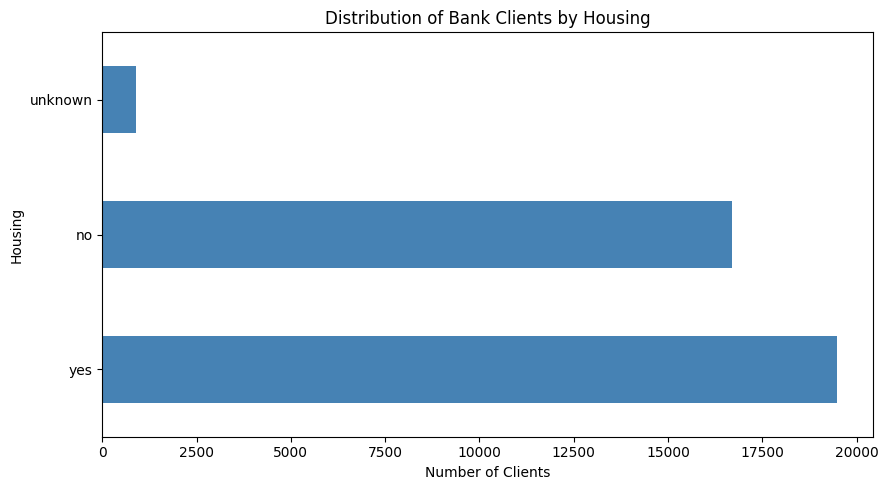

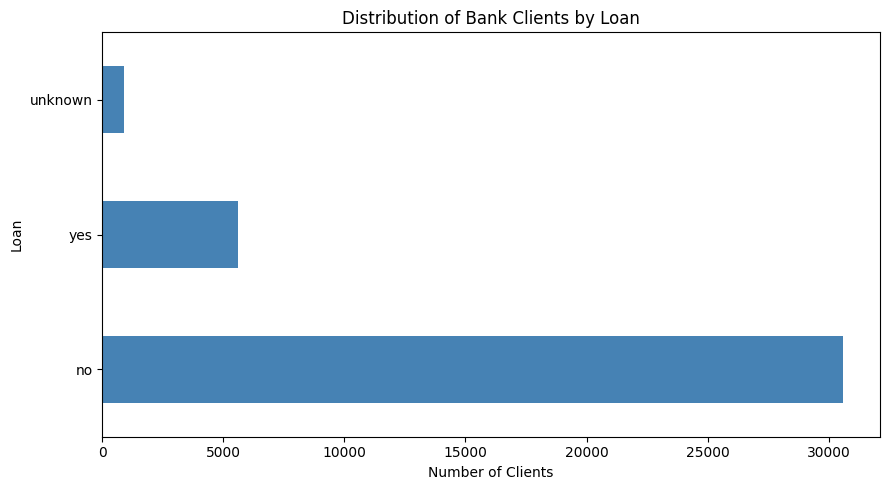

In [13]:
### Angela Chen
from pathlib import Path
 
import matplotlib.pyplot as plt
import pandas as pd
 
# Load the dataset from the actual project folder
url = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv" 
df = pd.read_csv(url)
 
# Columns to analyze
categorical_columns = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
]
 
# 1. Age distribution
plt.figure(figsize=(9, 5))
df["age"].plot(kind="hist", bins=20, edgecolor="black")
plt.title("Distribution of Bank Clients by Age")
plt.xlabel("Age")
plt.ylabel("Number of Clients")
plt.tight_layout()
plt.show()
 
# 2-7. Categorical distributions
for column in categorical_columns:
    counts = df[column].value_counts().sort_values(ascending=False)
 
    plt.figure(figsize=(9, 5))
    counts.plot(kind="barh", color="steelblue")
    plt.title(f"Distribution of Bank Clients by {column.title()}")
    plt.xlabel("Number of Clients")
    plt.ylabel(column.title())
    plt.tight_layout()
    plt.show()
 


Accuracy: 0.8864310763420555
              precision    recall  f1-score   support

           0       0.89      1.00      0.94      6572
           1       0.00      0.00      0.00       842

    accuracy                           0.89      7414
   macro avg       0.44      0.50      0.47      7414
weighted avg       0.79      0.89      0.83      7414

[[6572    0]
 [ 842    0]]


c:\Users\chanc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chanc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\chanc\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

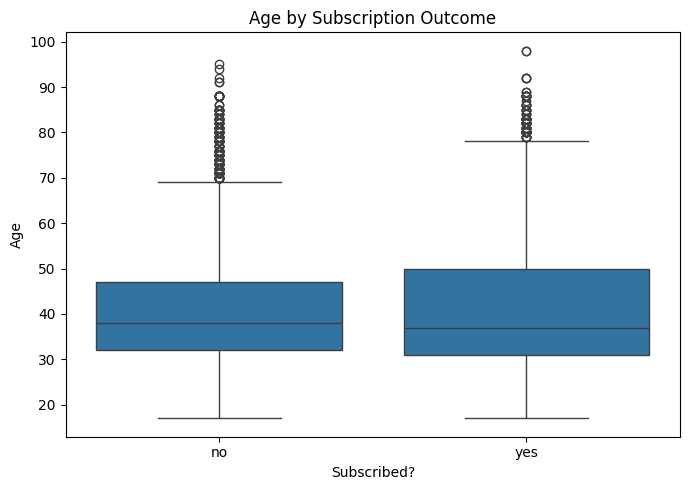

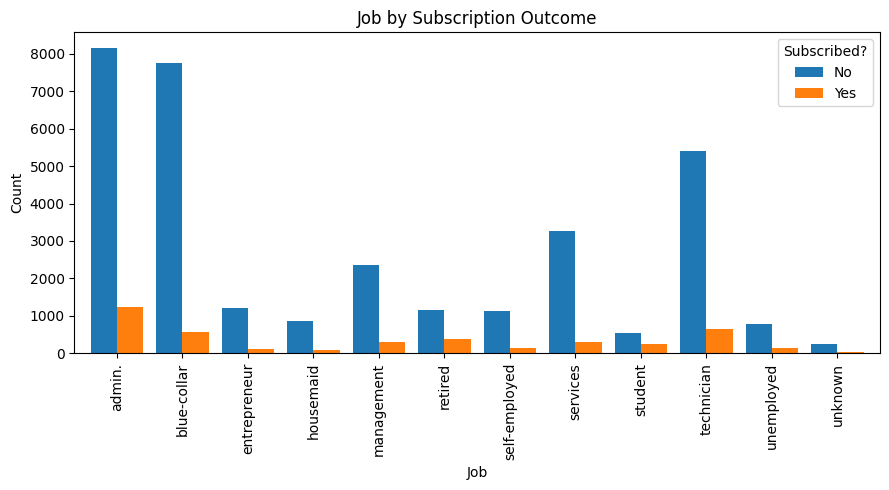

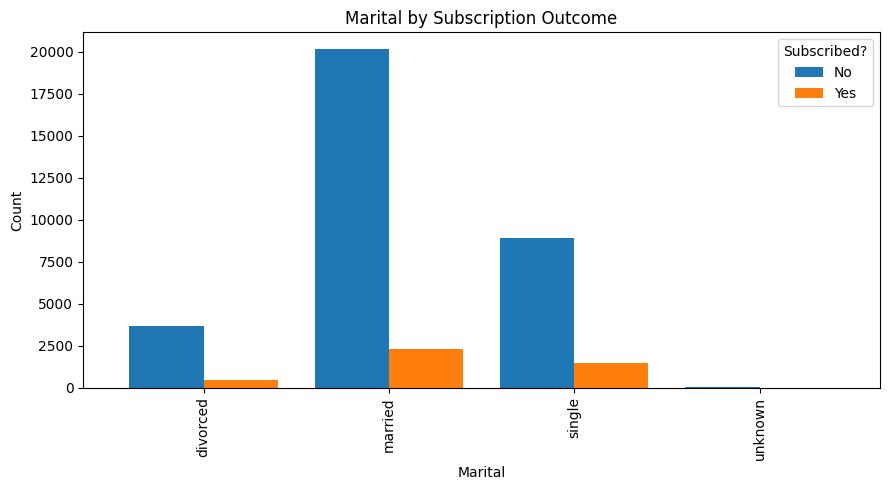

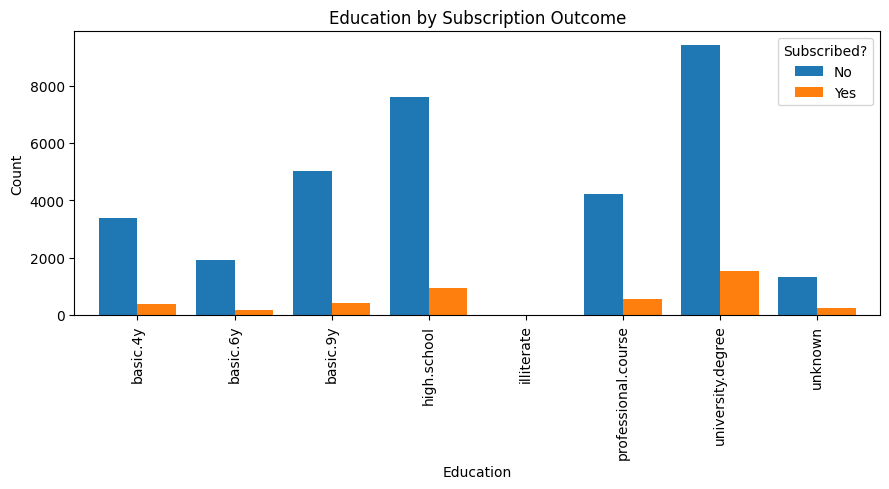

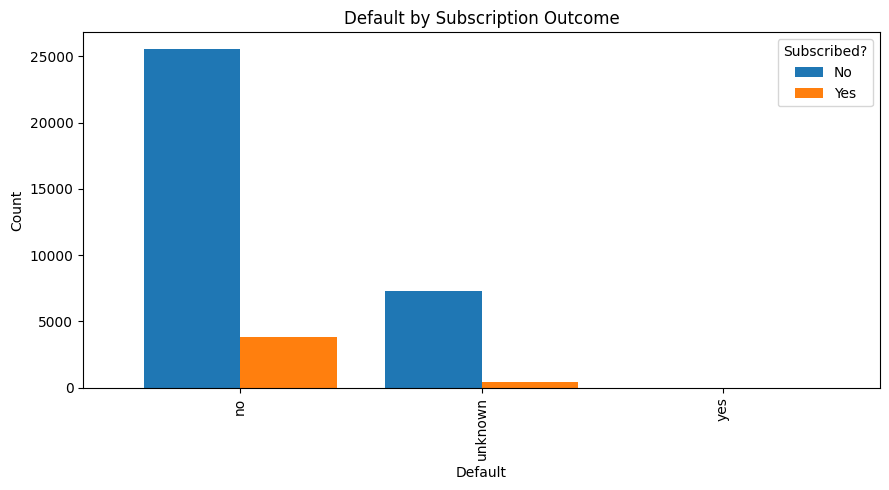

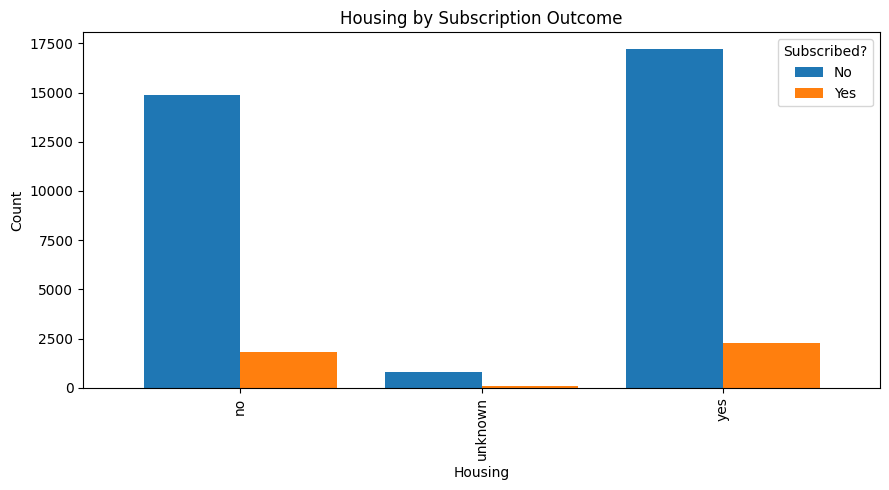

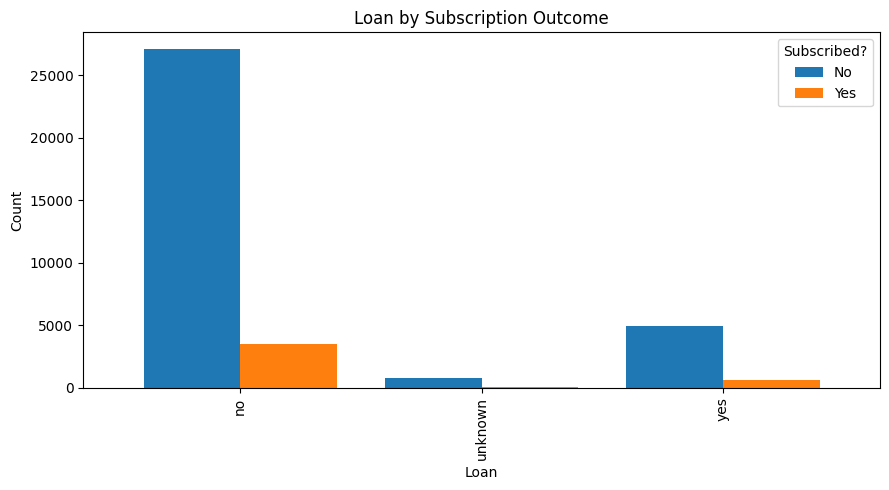

In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
 
# Load the dataset
# The bank dataset is in the cse450-bank-client folder
 
url = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv" 
df = pd.read_csv(url)
 
# Features to use for prediction
features = ["age", "job", "marital", "education", "default", "housing", "loan"]
target = "y"
 
X = df[features]
y = df[target].map({"no": 0, "yes": 1})
 
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
 
# Define preprocessing for numeric and categorical columns
numeric_features = ["age"]
categorical_features = ["job", "marital", "education", "default", "housing", "loan"]
 
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            Pipeline(
                [
                    ("imputer", SimpleImputer(strategy="median")),
                    ("scaler", StandardScaler()),
                ]
            ),
            numeric_features,
        ),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)
 
# Train a logistic regression model for yes/no prediction
model = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000)),
    ]
)
 
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
 
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
 
# Graph 1: age vs yes/no
plt.figure(figsize=(7, 5))
sns.boxplot(data=df, x="y", y="age")
plt.title("Age by Subscription Outcome")
plt.xlabel("Subscribed?")
plt.ylabel("Age")
plt.tight_layout()
plt.show()
 
# Graphs 2-7: categorical features vs yes/no
# Side-by-side bars make it easier to see who predicts yes vs no
for col in ["job", "marital", "education", "default", "housing", "loan"]:
    grouped = df.groupby([col, "y"]).size().unstack(fill_value=0)
    grouped = grouped.reindex(index=grouped.index.sort_values(), columns=["no", "yes"])
 
    grouped.plot(kind="bar", figsize=(9, 5), width=0.8)
    plt.title(f"{col.title()} by Subscription Outcome")
    plt.xlabel(col.title())
    plt.ylabel("Count")
    plt.legend(title="Subscribed?", labels=["No", "Yes"])
    plt.tight_layout()
    plt.show()

## This was the work that was done by Audrey Rentz

Findings

1. **Prior campaign outcome is the strongest signal.** Customers who subscribed in the last campaign subscribed again 65.8% of the time, versus 8.9% for customers never contacted before and 11.4% overall.
2. **Month matters a lot, mostly because of the economy.** March, December, September, and October had subscription rates of 45 to 51%, versus 6.5% in May. Those four months had low interest rates and few customers (158 to 653 each).
3. **Day of the week matters little.** Rates range from 9.9% (Monday) to 12.4% (Thursday). The data has weekdays only, so Saturday cannot be tested.
4. **Cellular outperforms telephone in the busiest months, but the overall gap is not that large.** Cellular is 14.9% vs. 5.3% overall, but 11,494 of the 13,554 telephone calls were made in May and June, the weakest months.
5. **More contacts goes with lower success.** The rate falls from 13.1% on the first contact to about 5% by the tenth. This could suggest diminishing returns, but doesn't prove extra calls cause refusals, because customers who say yes stop being called.


11.35% of customers subscribed


,rate,customers
poutcome,,
failure,14.3,3843
nonexistent,8.9,31988
success,65.8,1238


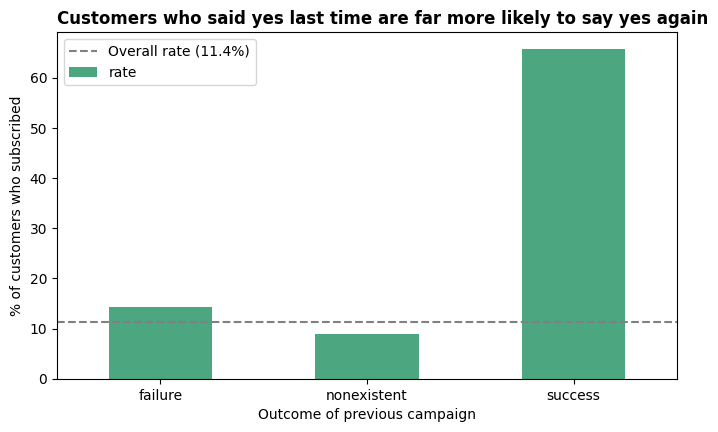

,rate,customers
month,,
mar,50.8,496
apr,20.9,2369
may,6.5,12370
jun,10.4,4817
jul,9.1,6445
aug,10.5,5555
sep,46.5,508
oct,44.6,653
nov,10.3,3698


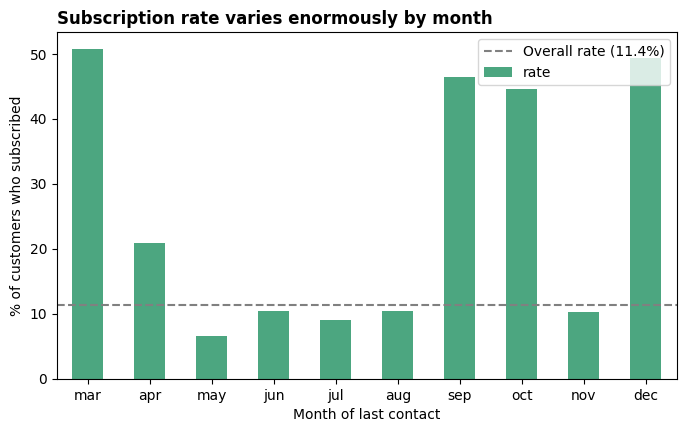

,rate,customers,euribor,emp_var
month,,,,
mar,50.8,496,1.16,-1.80
apr,20.9,2369,1.36,-1.80
may,6.5,12370,3.30,-0.16
jun,10.4,4817,4.25,0.68
jul,9.1,6445,4.68,1.16
aug,10.5,5555,4.30,0.74
sep,46.5,508,0.83,-2.19
oct,44.6,653,1.22,-2.41
nov,10.3,3698,3.71,-0.43


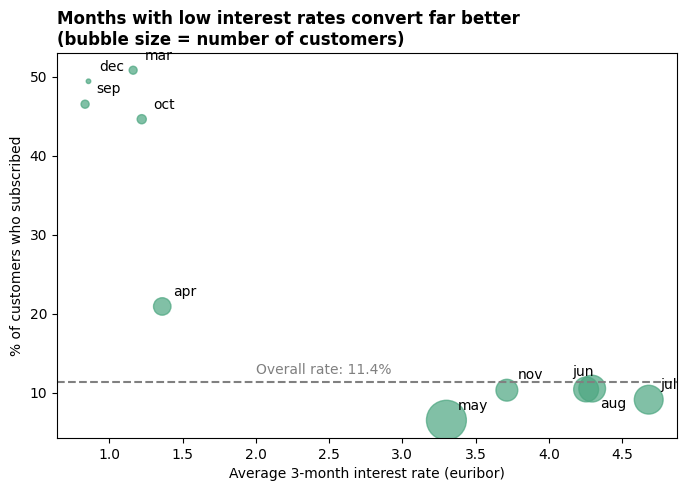

poutcome,failure,nonexistent,success
month,,,
mar,90,334,72
apr,579,1692,98
may,1599,10565,206
jun,158,4531,128
jul,109,6235,101
aug,231,5139,185
sep,121,253,134
oct,154,373,126
nov,767,2783,148


poutcome,failure,nonexistent,success
month,,,
mar,40.0,47.0,81.9
apr,11.4,21.8,62.2
may,7.5,5.4,51.0
jun,30.4,8.2,65.6
jul,40.4,7.5,75.2
aug,30.7,7.7,63.8
sep,30.6,36.4,79.9
oct,33.1,40.2,71.4
nov,8.7,8.2,58.1


,rate,customers
day_of_week,,
mon,9.9,7657
tue,11.8,7287
wed,11.8,7347
thu,12.4,7742
fri,10.9,7036


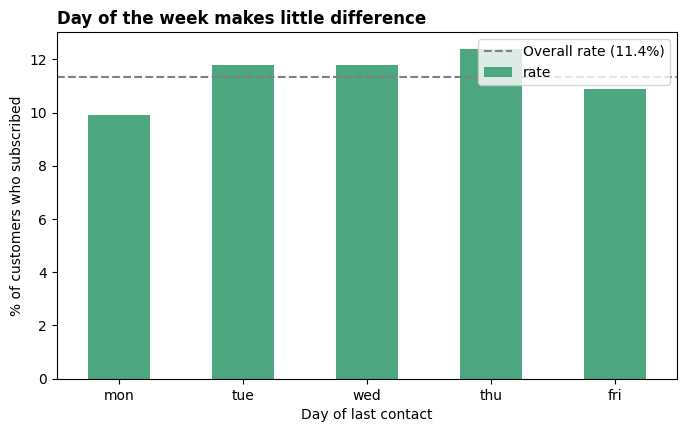

,rate,customers
contact,,
cellular,14.9,23515
telephone,5.3,13554


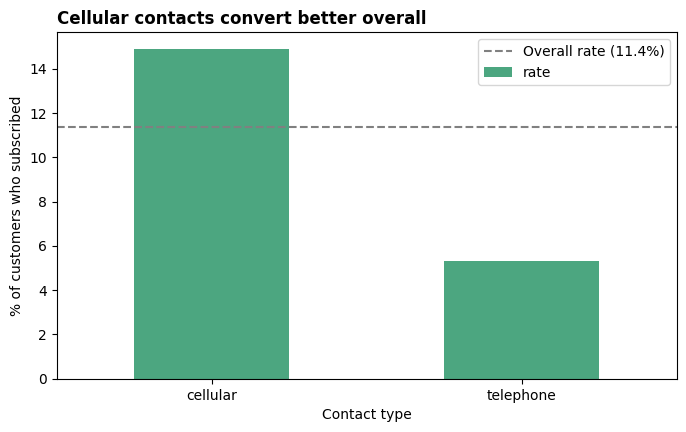

contact,cellular,telephone
month,,
mar,443,53
apr,2200,169
may,4943,7427
jun,750,4067
jul,5486,959
aug,5311,244
sep,427,81
oct,511,142
nov,3313,385


contact,cellular,telephone
month,,
mar,51.9,41.5
apr,20.5,27.2
may,11.3,3.2
jun,41.9,4.6
jul,9.8,5.2
aug,10.4,13.1
sep,51.3,21.0
oct,45.0,43.0
nov,10.1,11.9


,rate,customers
campaign_capped,,
1,13.1,15874
2,11.4,9554
3,11.0,4804
4,9.5,2378
5,7.6,1432
6,7.8,855
7,6.6,559
8,4.1,363
9,6.4,265


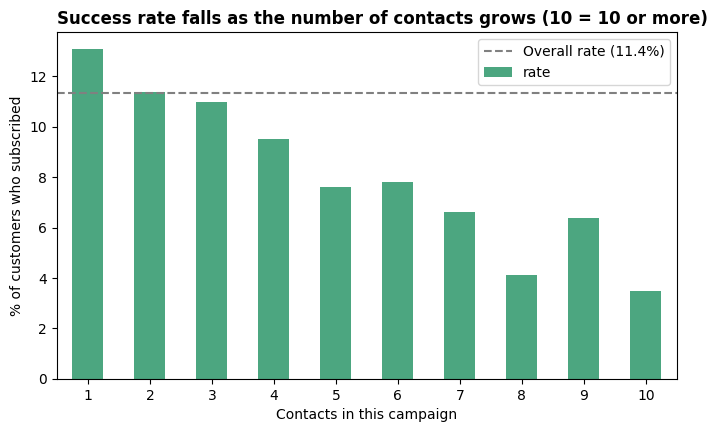

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

# Setup and Data Loading
df = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv')
hold = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank_holdout_test.csv')

df['subscribed'] = (df['y'] == 'yes').astype(int)
GREEN = '#4ca680'
MONTHS = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

# Helper Functions
def rate_by(col, order=None):
    t = df.groupby(col)['subscribed'].agg(rate='mean', customers='size')
    t['rate'] = (t['rate'] * 100).round(1)
    if order:
        t = t.reindex([o for o in order if o in t.index])
    return t

def rate_chart(t, title, xlabel):
    ax = t['rate'].plot(kind='bar', color=GREEN, figsize=(8, 4.5))
    ax.axhline(BASELINE, ls='--', color='gray', label=f'Overall rate ({BASELINE:.1f}%)')
    ax.set_title(title, loc='left', fontweight='bold')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('% of customers who subscribed')
    ax.legend()
    plt.xticks(rotation=0)
    plt.show()

# Baseline
BASELINE = df['subscribed'].mean() * 100
print(f'{BASELINE:.2f}% of customers subscribed')

# 1. Prior campaign outcome
poutcome = rate_by('poutcome')
display(poutcome)
rate_chart(poutcome, 'Customers who said yes last time are far more likely to say yes again', 'Outcome of previous campaign')

# 2. Month and the economy
month = rate_by('month', order=MONTHS)
display(month)
rate_chart(month, 'Subscription rate varies enormously by month', 'Month of last contact')

economy = df.groupby('month').agg(
    rate=('subscribed', 'mean'),
    customers=('subscribed', 'size'),
    euribor=('euribor3m', 'mean'),
    emp_var=('emp.var.rate', 'mean')
).reindex([m for m in MONTHS if m in set(df['month'])])
economy['rate'] = (economy['rate'] * 100).round(1)
display(economy.round(2))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(economy['euribor'], economy['rate'], s=economy['customers'] / 15, color=GREEN, alpha=0.7)
offsets = {'jun': (-10, 10), 'aug': (6, -14)}      
for name, r in economy.iterrows():
    ax.annotate(name, (r['euribor'], r['rate']), xytext=offsets.get(name, (8, 8)), textcoords='offset points')
ax.axhline(BASELINE, ls='--', color='gray')
ax.text(2.0, BASELINE + 1, f'Overall rate: {BASELINE:.1f}%', color='gray')
ax.set_xlabel('Average 3-month interest rate (euribor)')
ax.set_ylabel('% of customers who subscribed')
ax.set_title('Months with low interest rates convert far better\n(bubble size = number of customers)', loc='left', fontweight='bold')
plt.show()

display(pd.crosstab(df['month'], df['poutcome']).reindex([m for m in MONTHS if m in set(df['month'])]))
display((df.groupby(['month', 'poutcome'])['subscribed'].mean().unstack() * 100).round(1).reindex([m for m in MONTHS if m in set(df['month'])]))

# 3. Day of the week
day = rate_by('day_of_week', order=['mon', 'tue', 'wed', 'thu', 'fri', 'sat', 'sun'])
display(day)
rate_chart(day, 'Day of the week makes little difference', 'Day of last contact')

# 4. Contact type
contact = rate_by('contact')
display(contact)
rate_chart(contact, 'Cellular contacts convert better overall', 'Contact type')

display(pd.crosstab(df['month'], df['contact']).reindex([m for m in MONTHS if m in set(df['month'])]))
display((df.groupby(['month', 'contact'])['subscribed'].mean().unstack() * 100).round(1).reindex([m for m in MONTHS if m in set(df['month'])]))

# 5. Number of contacts in the campaign
df['campaign_capped'] = df['campaign'].clip(upper=10)       
contacts = df.groupby('campaign_capped')['subscribed'].agg(rate='mean', customers='size')
contacts['rate'] = (contacts['rate'] * 100).round(1)
display(contacts)
rate_chart(contacts, 'Success rate falls as the number of contacts grows (10 = 10 or more)', 'Contacts in this campaign')

# This was the work done by Jacob Lamb

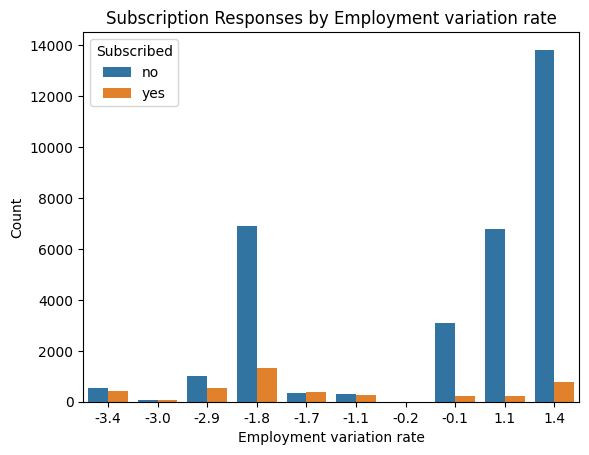

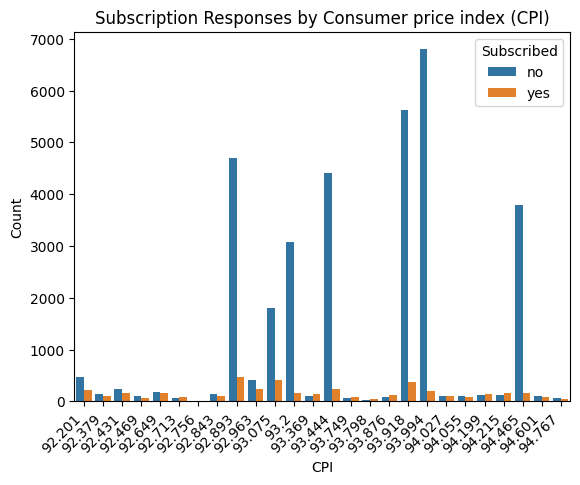

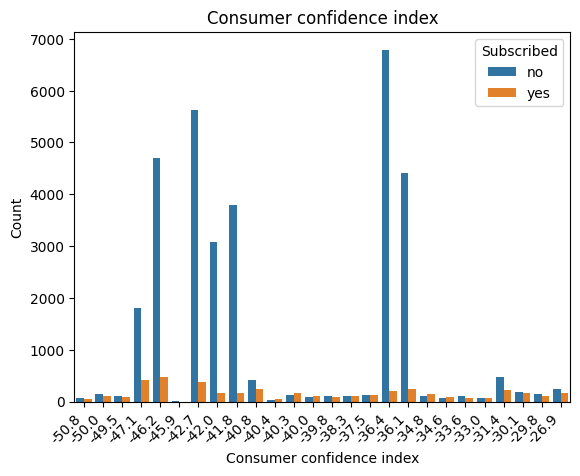

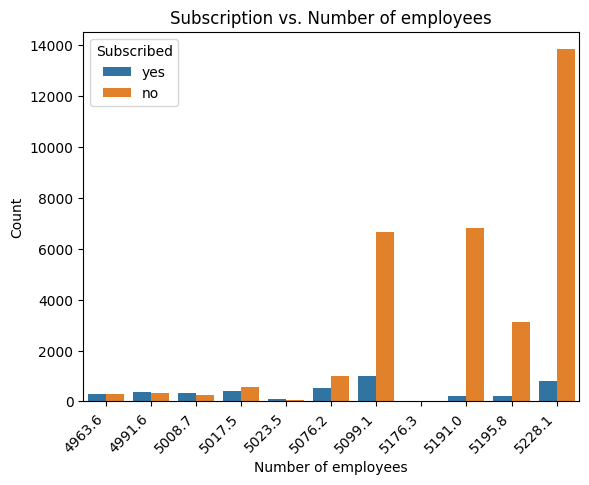

C:\Users\chanc\AppData\Local\Temp\ipykernel_11248\3353467062.py:61: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title='Subscribed')


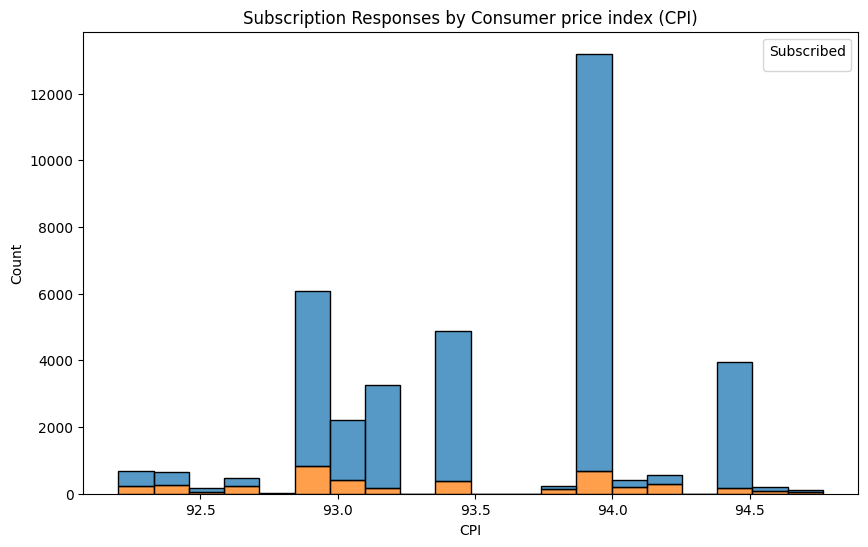

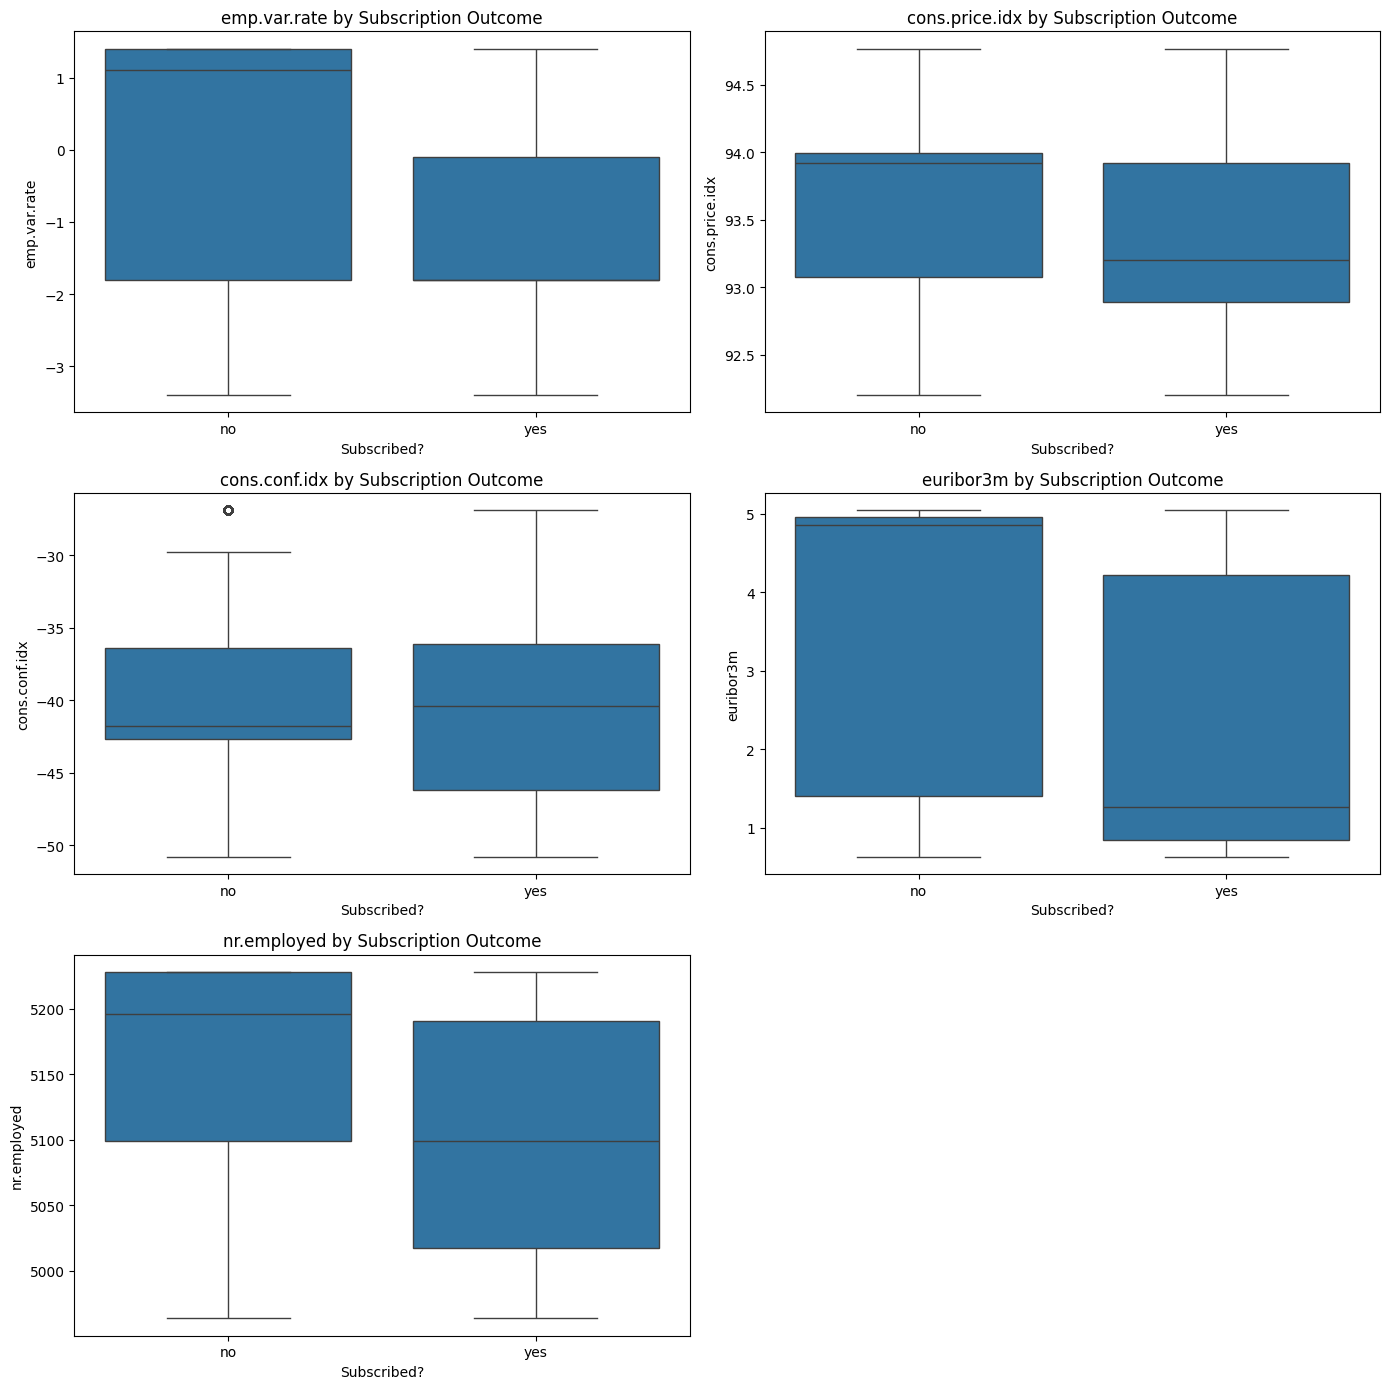

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

campaign = pd.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv')

# import polars as pl
# campaign = pl.read_csv('https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv', schema_overrides={'nr.employed': pl.Float64})


#Box plots of all economic factors
# Subscription Responses by Employment variation rate
sns.countplot(data=campaign, x='emp.var.rate', hue='y')
plt.title('Subscription Responses by Employment variation rate')
plt.xlabel('Employment variation rate')
plt.ylabel('Count')
plt.legend(title='Subscribed')
plt.show()

# Subscription Responses by Consumer price index (CPI)
sns.countplot(data=campaign, x='cons.price.idx', hue='y')
plt.title('Subscription Responses by Consumer price index (CPI)')
plt.xlabel('CPI')
plt.ylabel('Count')
plt.legend(title='Subscribed')
plt.xticks(rotation=45, ha='right')
plt.show()

# Consumer confidence index
sns.countplot(data=campaign, x='cons.conf.idx', hue='y')
plt.title('Consumer confidence index')
plt.xlabel('Consumer confidence index')
plt.ylabel('Count')
plt.legend(title='Subscribed')
plt.xticks(rotation=45, ha='right')
plt.show()

# Subscription vs. Number of employees
sns.countplot(data=campaign, x='nr.employed', hue='y')
plt.title('Subscription vs. Number of employees')
plt.xlabel('Number of employees')
plt.ylabel('Count')
plt.legend(title='Subscribed')
plt.xticks(rotation=45, ha='right')
plt.show()

###  Histogram of Subscription Responses by Consumer price index (CPI)

plt.figure(figsize=(10, 6))
sns.histplot(
    data=campaign,
    x='cons.price.idx',
    hue='y',
    bins=20,
    multiple='stack',
)

plt.title('Subscription Responses by Consumer price index (CPI)')
plt.xlabel('CPI')
plt.ylabel('Count')
plt.legend(title='Subscribed')

#plt.tight_layout()
plt.show()


### Box Plot of all Econmoic factors
economic_columns = [
    'emp.var.rate',
    'cons.price.idx',
    'cons.conf.idx',
    'euribor3m',
    'nr.employed'
]

fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for i, col in enumerate(economic_columns):
    sns.boxplot(
        data=campaign,
        x='y',
        y=col,
        ax=axes[i]
    )

    axes[i].set_title(f'{col} by Subscription Outcome')
    axes[i].set_xlabel('Subscribed?')
    axes[i].set_ylabel(col)

# Remove the unused sixth plot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

# This was the work done by Chance Edwards

Model Accuracy: 89.72%

Confusion Matrix:



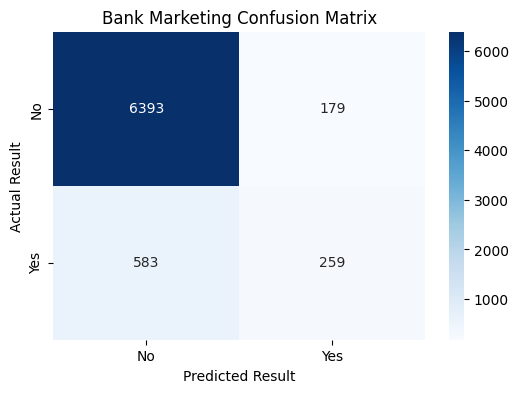

Classifcation Report:
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      6572
           1       0.59      0.31      0.40       842

    accuracy                           0.90      7414
   macro avg       0.75      0.64      0.67      7414
weighted avg       0.88      0.90      0.88      7414

Top Feature Importances:
age             0.164207
euribor3m       0.149458
campaign        0.083192
job             0.080904
education       0.074958
nr.employed     0.073400
day_of_week     0.059533
emp.var.rate    0.051311
marital         0.039245
housing         0.032377
dtype: float64


In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder  ## looks at the columns for the unique text and will give and interger to each one
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix ## Confusion matrix will tell me the overall percentage of correct guesses


### 1. Load the data set
url = "https://raw.githubusercontent.com/byui-cse/cse450-course/master/data/bank.csv"
model_df = pd.read_csv(url)
print

# Label encoder that will convert text back to numbers
label_encoder = {}
for column in model_df.select_dtypes(include=['object']).columns:
    if column != 'y':
        le = LabelEncoder()
        model_df[column] = le.fit_transform(model_df[column].astype(str))
        label_encoder[column] = le

# Mapping the target variable 'y', 1 for yes and 0 for no
model_df['y'] = model_df['y'].map({'yes': 1, 'no': 0})

# Separate features (X) and the target varaible (y)
X = model_df.drop(columns=['y'])
y = model_df['y']

### 2. Performing the split
## The 80-20 split, test_size = 0.2 which means that the test will only do 20% of the data and 80% training.
# this random_state ensures the split is reproducible for the train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

### 3. Training the model to using 80% of the data
model = RandomForestClassifier(n_estimators = 100, random_state = 42, class_weight = 'balanced') # Random seed, think of the seed for Minecraft
model.fit(X_train, y_train)

### 4. Testign the model using the 20% unseen testing data
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)*100
print(f"Model Accuracy: {accuracy:.2f}%\n")

print("Confusion Matrix:\n") # This prints a 3x3 grid showing correct vs incorrect guesses

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No', 'Yes'], 
            yticklabels=['No', 'Yes'])

plt.ylabel('Actual Result')
plt.xlabel('Predicted Result')
plt.title('Bank Marketing Confusion Matrix')

plt.show()

print("Classifcation Report:")
print(classification_report(y_test, y_pred))

# Feature Importance Analysis
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
print("Top Feature Importances:")
print(importances.head(10))